# Customer Geographics & Payment Value Distribution EDA
### Olist Brazilian E-Commerce Dataset

This notebook generates two core exploratory visualizations:
1. **Top 10 Customer States** by distinct order volume.
2. **Distribution of Payment Value** (Histogram + KDE overlay, truncated at the 95th percentile to highlight the primary transaction density and remove extreme outliers).

In [1]:
import os
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns

# 1. Load Processed Master Dataset
data_path = os.path.join("..", "Data", "Processed", "df_master.csv") if os.path.exists(os.path.join("..", "Data", "Processed", "df_master.csv")) else os.path.join("Data", "Processed", "df_master.csv")
df_master = pd.read_csv(data_path)

print(f"Loaded df_master: {df_master.shape}")

Loaded df_master: (115035, 22)


## 2. Visualization 1: Top 10 Customer States by Total Orders
Count distinct orders per state using `order_id.nunique()`.

In [2]:
top_states = (
    df_master.groupby("customer_state")["order_id"]
    .nunique()
    .sort_values(ascending=False)
    .head(10)
    .reset_index()
    .rename(columns={"order_id": "order_count"})
)
total_unique_orders = df_master["order_id"].nunique()
top_states["percentage"] = (top_states["order_count"] / total_unique_orders) * 100
display(top_states)

,customer_state,order_count,percentage
0,SP,40500,41.978917
1,RJ,12350,12.800978
2,MG,11354,11.768608
3,RS,5345,5.540181
4,PR,4923,5.102771
5,SC,3546,3.675487
6,BA,3256,3.374898
7,DF,2080,2.155954
8,ES,1995,2.067850
9,GO,1957,2.028463


## 3. Visualization 2: Distribution of Payment Values (<= 95th Percentile)
Calculate summary metrics and truncate at the 95th percentile.

In [3]:
p95 = df_master["payment_value"].quantile(0.95)
mean_val = df_master["payment_value"].mean()
median_val = df_master["payment_value"].median()

print(f"Payment Value Metrics:")
print(f"- Mean:            R${mean_val:.2f}")
print(f"- Median:          R${median_val:.2f}")
print(f"- 95th Percentile: R${p95:.2f}")
print(f"- Max:             R${df_master['payment_value'].max():.2f}")

Payment Value Metrics:
- Mean:            R$171.91
- Median:          R$108.19
- 95th Percentile: R$510.98
- Max:             R$13664.08


## 4. Academic-Paper Ready Visualization Figures

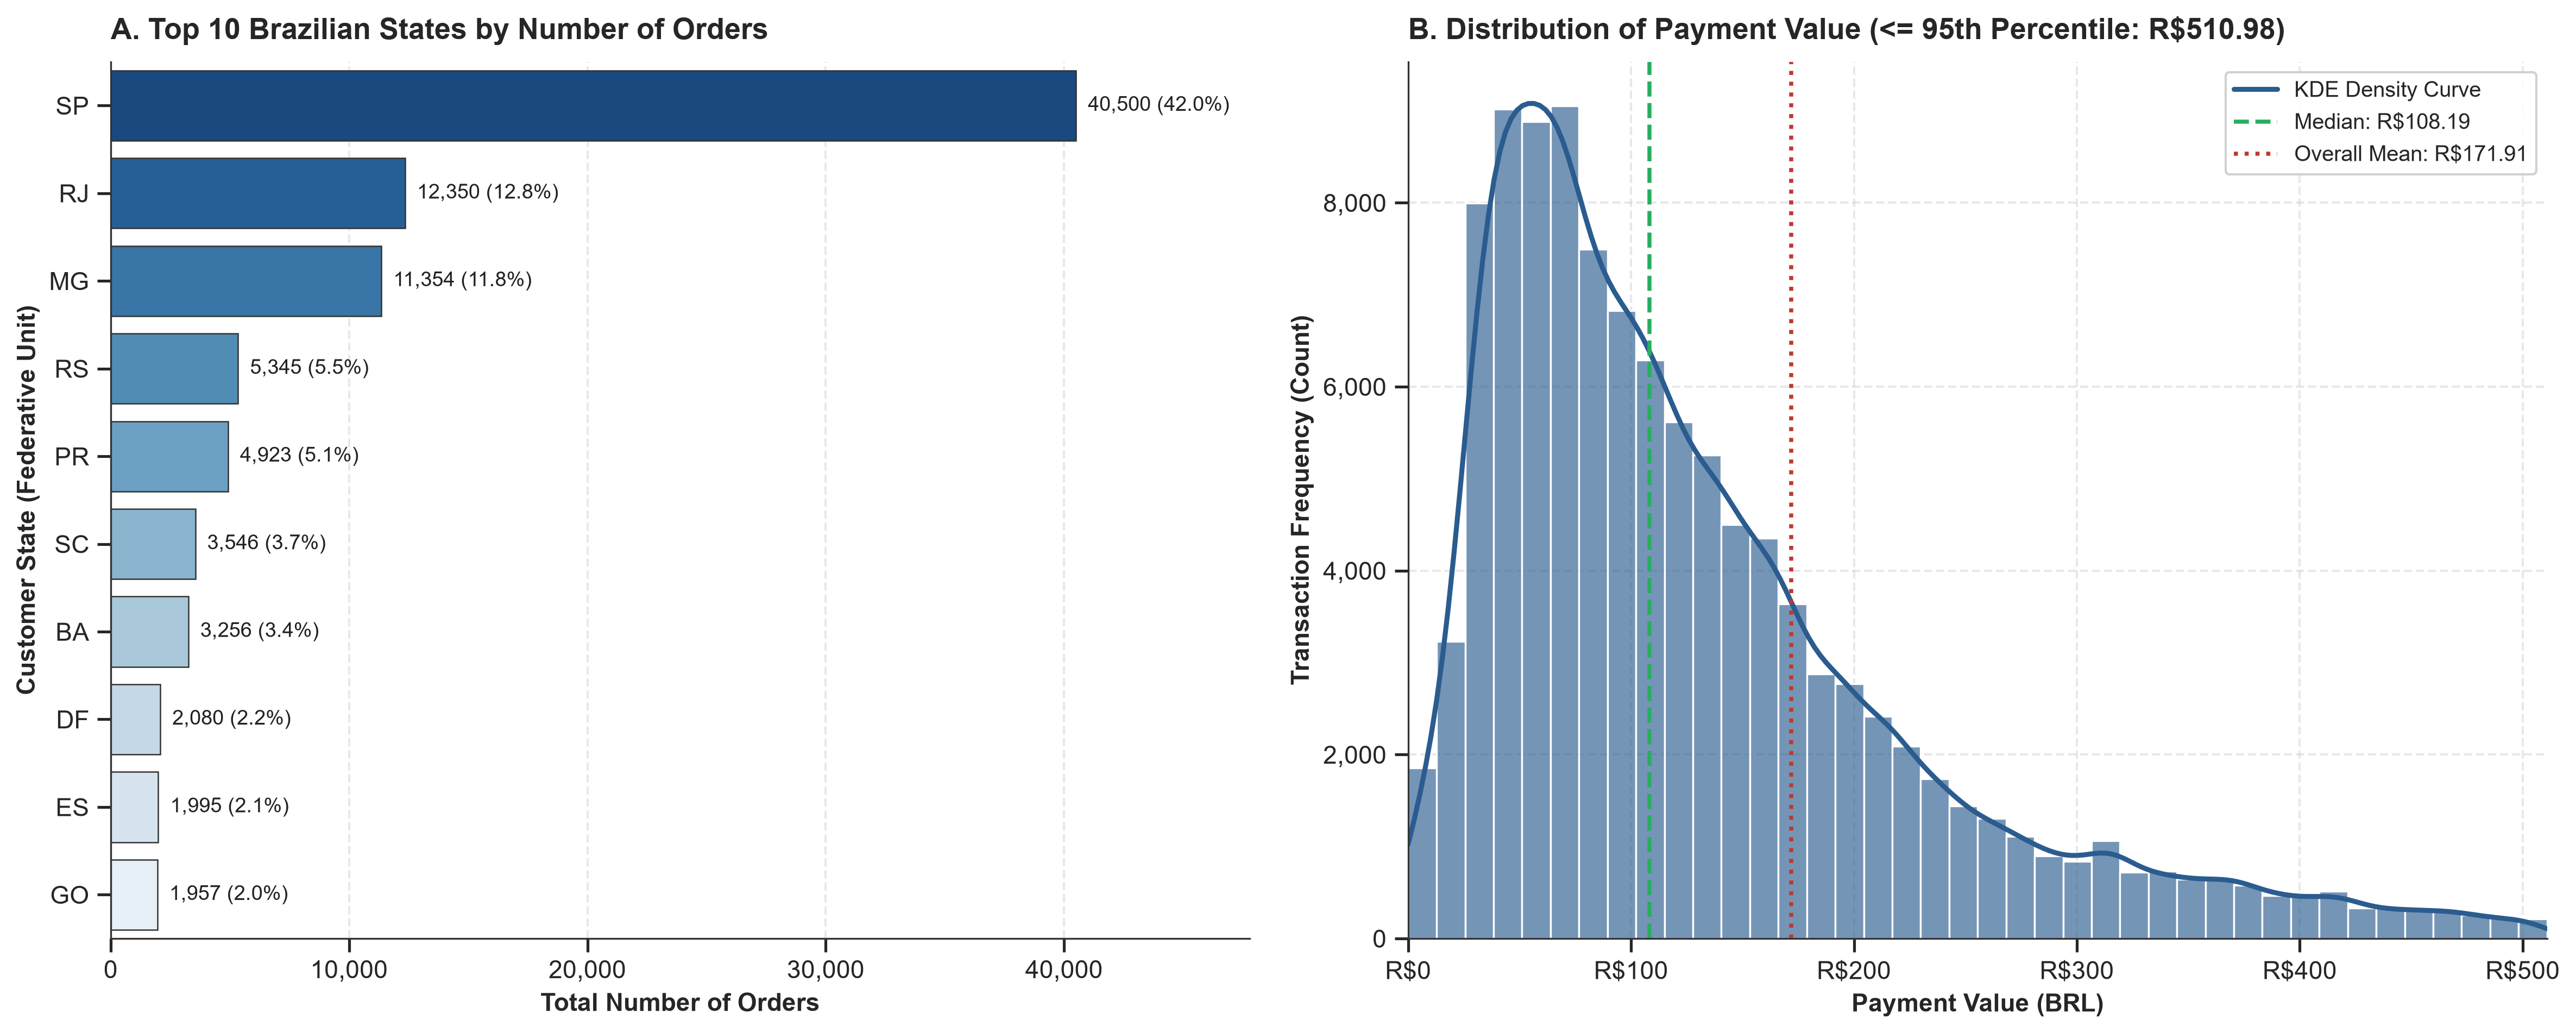

In [4]:
# Theme and layout setup
sns.set_theme(style="ticks", font="sans-serif")
plt.rcParams["axes.edgecolor"] = "#333333"
plt.rcParams["axes.linewidth"] = 0.8

PALETTE_BAR = sns.color_palette("Blues_r", n_colors=10)
COLOR_HIST = "#2B5C8F"
COLOR_KDE = "#D95F02"

fig, (ax1, ax2) = plt.subplots(nrows=1, ncols=2, figsize=(16, 6.5), dpi=300)

# ---------------------------------------------------------
# Panel A: Top 10 States Horizontal Bar Chart
# ---------------------------------------------------------
sns.barplot(
    data=top_states,
    y="customer_state",
    x="order_count",
    hue="customer_state",
    palette=PALETTE_BAR,
    legend=False,
    ax=ax1,
    edgecolor="#333333",
    linewidth=0.6
)

ax1.set_title("A. Top 10 Brazilian States by Number of Orders", fontsize=13, fontweight="bold", loc="left", pad=10)
ax1.set_xlabel("Total Number of Orders", fontsize=11, fontweight="bold")
ax1.set_ylabel("Customer State (Federative Unit)", fontsize=11, fontweight="bold")
ax1.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax1.grid(True, axis="x", linestyle="--", alpha=0.45)
sns.despine(ax=ax1, top=True, right=True)

# Value annotations at the end of each bar
for i, bar in enumerate(ax1.patches):
    count = int(bar.get_width())
    pct = (count / total_unique_orders) * 100
    ax1.text(
        bar.get_width() + 500,
        bar.get_y() + bar.get_height() / 2,
        f"{count:,} ({pct:.1f}%)",
        va="center",
        ha="left",
        fontsize=9,
        color="#222222"
    )
ax1.set_xlim(0, top_states["order_count"].max() * 1.18)

# ---------------------------------------------------------
# Panel B: Histogram + KDE (<= 95th percentile)
# ---------------------------------------------------------
df_filtered_pv = df_master[df_master["payment_value"] <= p95]

sns.histplot(
    data=df_filtered_pv,
    x="payment_value",
    bins=40,
    kde=True,
    color=COLOR_HIST,
    edgecolor="white",
    linewidth=0.8,
    alpha=0.65,
    ax=ax2,
    line_kws={"color": COLOR_KDE, "linewidth": 2.2, "label": "KDE Density Curve"}
)

# Vertical reference lines for Median and Mean
ax2.axvline(median_val, color="#27AE60", linestyle="--", linewidth=1.8, label=f"Median: R${median_val:.2f}")
ax2.axvline(mean_val, color="#C0392B", linestyle=":", linewidth=1.8, label=f"Overall Mean: R${mean_val:.2f}")

ax2.set_title(f"B. Distribution of Payment Value (<= 95th Percentile: R${p95:.2f})", fontsize=13, fontweight="bold", loc="left", pad=10)
ax2.set_xlabel("Payment Value (BRL)", fontsize=11, fontweight="bold")
ax2.set_ylabel("Transaction Frequency (Count)", fontsize=11, fontweight="bold")
ax2.xaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"R${int(x)}"))
ax2.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x, p: f"{int(x):,}"))
ax2.set_xlim(0, p95)
ax2.grid(True, linestyle="--", alpha=0.45)
ax2.legend(loc="upper right", frameon=True, framealpha=0.9, fontsize=9.5)
sns.despine(ax=ax2, top=True, right=True)

plt.tight_layout()

# Save figure to Results folder
results_dir = os.path.join("..", "Results") if os.path.exists(os.path.join("..", "Results")) else "Results"
os.makedirs(results_dir, exist_ok=True)
plt.savefig(os.path.join(results_dir, "eda_state_and_payment_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()